In [3]:
# 1. Imports and Data Loading
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

music_data = pd.read_csv('music.csv')
X = music_data.drop(columns=['genre'])
y = music_data['genre']

# 2. Train/Test Split & Accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
score = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {score * 100:.2f}%")

# 3. Model Persistence (Save & Load)
# Retrain on full data for export
full_model = DecisionTreeClassifier()
full_model.fit(X, y)
joblib.dump(full_model, 'music-recommender.joblib')

# Load the model from disk and run a sample prediction
loaded_model = joblib.load('music-recommender.joblib')
sample_pred = loaded_model.predict([[21, 1], [22, 0]])
print("Predictions for [21M, 22F]:", sample_pred)

Model Accuracy: 100.00%
Predictions for [21M, 22F]: ['HipHop' 'Dance']


c:\Users\Nisar\OneDrive\Documents\vs code\python\music-recommender-ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


--- Classification Report ---
              precision    recall  f1-score   support

    Acoustic       1.00      1.00      1.00         1
   Classical       1.00      1.00      1.00         2
      HipHop       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



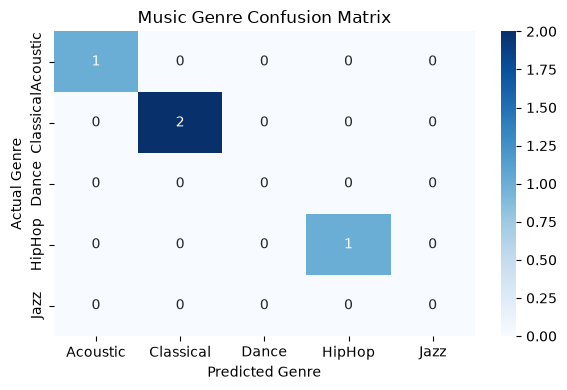

In [4]:
# Model Evaluation: Classification Report & Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Predictions on the test set
predictions = model.predict(X_test)

# Precision, recall, and f1-score
print("--- Classification Report ---")
print(classification_report(y_test, predictions, zero_division=0))

# Generate and plot confusion matrix
cm = confusion_matrix(y_test, predictions, labels=model.classes_)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Music Genre Confusion Matrix')
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()